# Import Packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Loading and exploring the dataset

In [2]:
train_df = pd.read_csv('../input/competitions/house-prices-advanced-regression-techniques/train.csv')

In [3]:
train_df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train_df.shape

(1460, 81)

In [5]:
train_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [6]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
train_df.describe(include='object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


# data cleaning

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [9]:
train_df.isna().sum().sort_values(ascending = False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [10]:
print("Total training examples:", train_df.shape[0])
print("Duplicate rows:", train_df.duplicated().sum())

Total training examples: 1460
Duplicate rows: 0


In [11]:
train_df = train_df[['OverallQual', 'GrLivArea', 'GarageCars',
                         'TotalBsmtSF', '1stFlrSF', 'FullBath', 
                         'TotRmsAbvGrd','YearBuilt', 'SalePrice']]

In [12]:
train_df.head(5)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,SalePrice
0,7,1710,2,856,856,2,8,2003,208500
1,6,1262,2,1262,1262,2,6,1976,181500
2,7,1786,2,920,920,2,6,2001,223500
3,7,1717,3,756,961,1,7,1915,140000
4,8,2198,3,1145,1145,2,9,2000,250000


In [13]:
train_df.shape

(1460, 9)

In [14]:
train_df.describe()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1162.626712,1.565068,6.517808,1971.267808,180921.195890
std,1.382997,525.480383,0.747315,438.705324,386.587738,0.550916,1.625393,30.202904,79442.502883
min,1.000000,334.000000,0.000000,0.000000,334.000000,0.000000,2.000000,1872.000000,34900.000000
25%,5.000000,1129.500000,1.000000,795.750000,882.000000,1.000000,5.000000,1954.000000,129975.000000
50%,6.000000,1464.000000,2.000000,991.500000,1087.000000,2.000000,6.000000,1973.000000,163000.000000
75%,7.000000,1776.750000,2.000000,1298.250000,1391.250000,2.000000,7.000000,2000.000000,214000.000000
max,10.000000,5642.000000,4.000000,6110.000000,4692.000000,3.000000,14.000000,2010.000000,755000.000000


In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OverallQual   1460 non-null   int64
 1   GrLivArea     1460 non-null   int64
 2   GarageCars    1460 non-null   int64
 3   TotalBsmtSF   1460 non-null   int64
 4   1stFlrSF      1460 non-null   int64
 5   FullBath      1460 non-null   int64
 6   TotRmsAbvGrd  1460 non-null   int64
 7   YearBuilt     1460 non-null   int64
 8   SalePrice     1460 non-null   int64
dtypes: int64(9)
memory usage: 102.8 KB


In [16]:
train_df.isna().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
SalePrice       0
dtype: int64

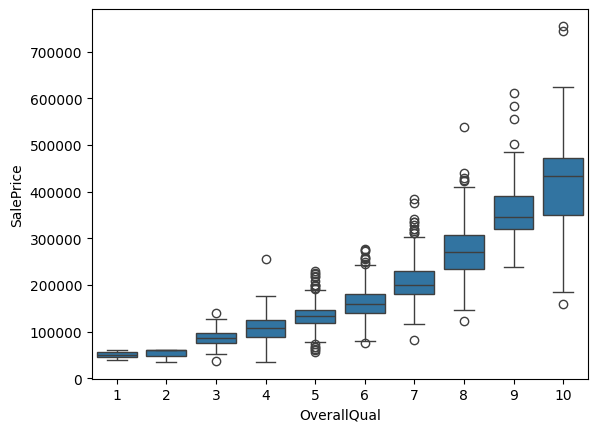

In [17]:
sns.boxplot(train_df, x='OverallQual', y='SalePrice')
plt.show()

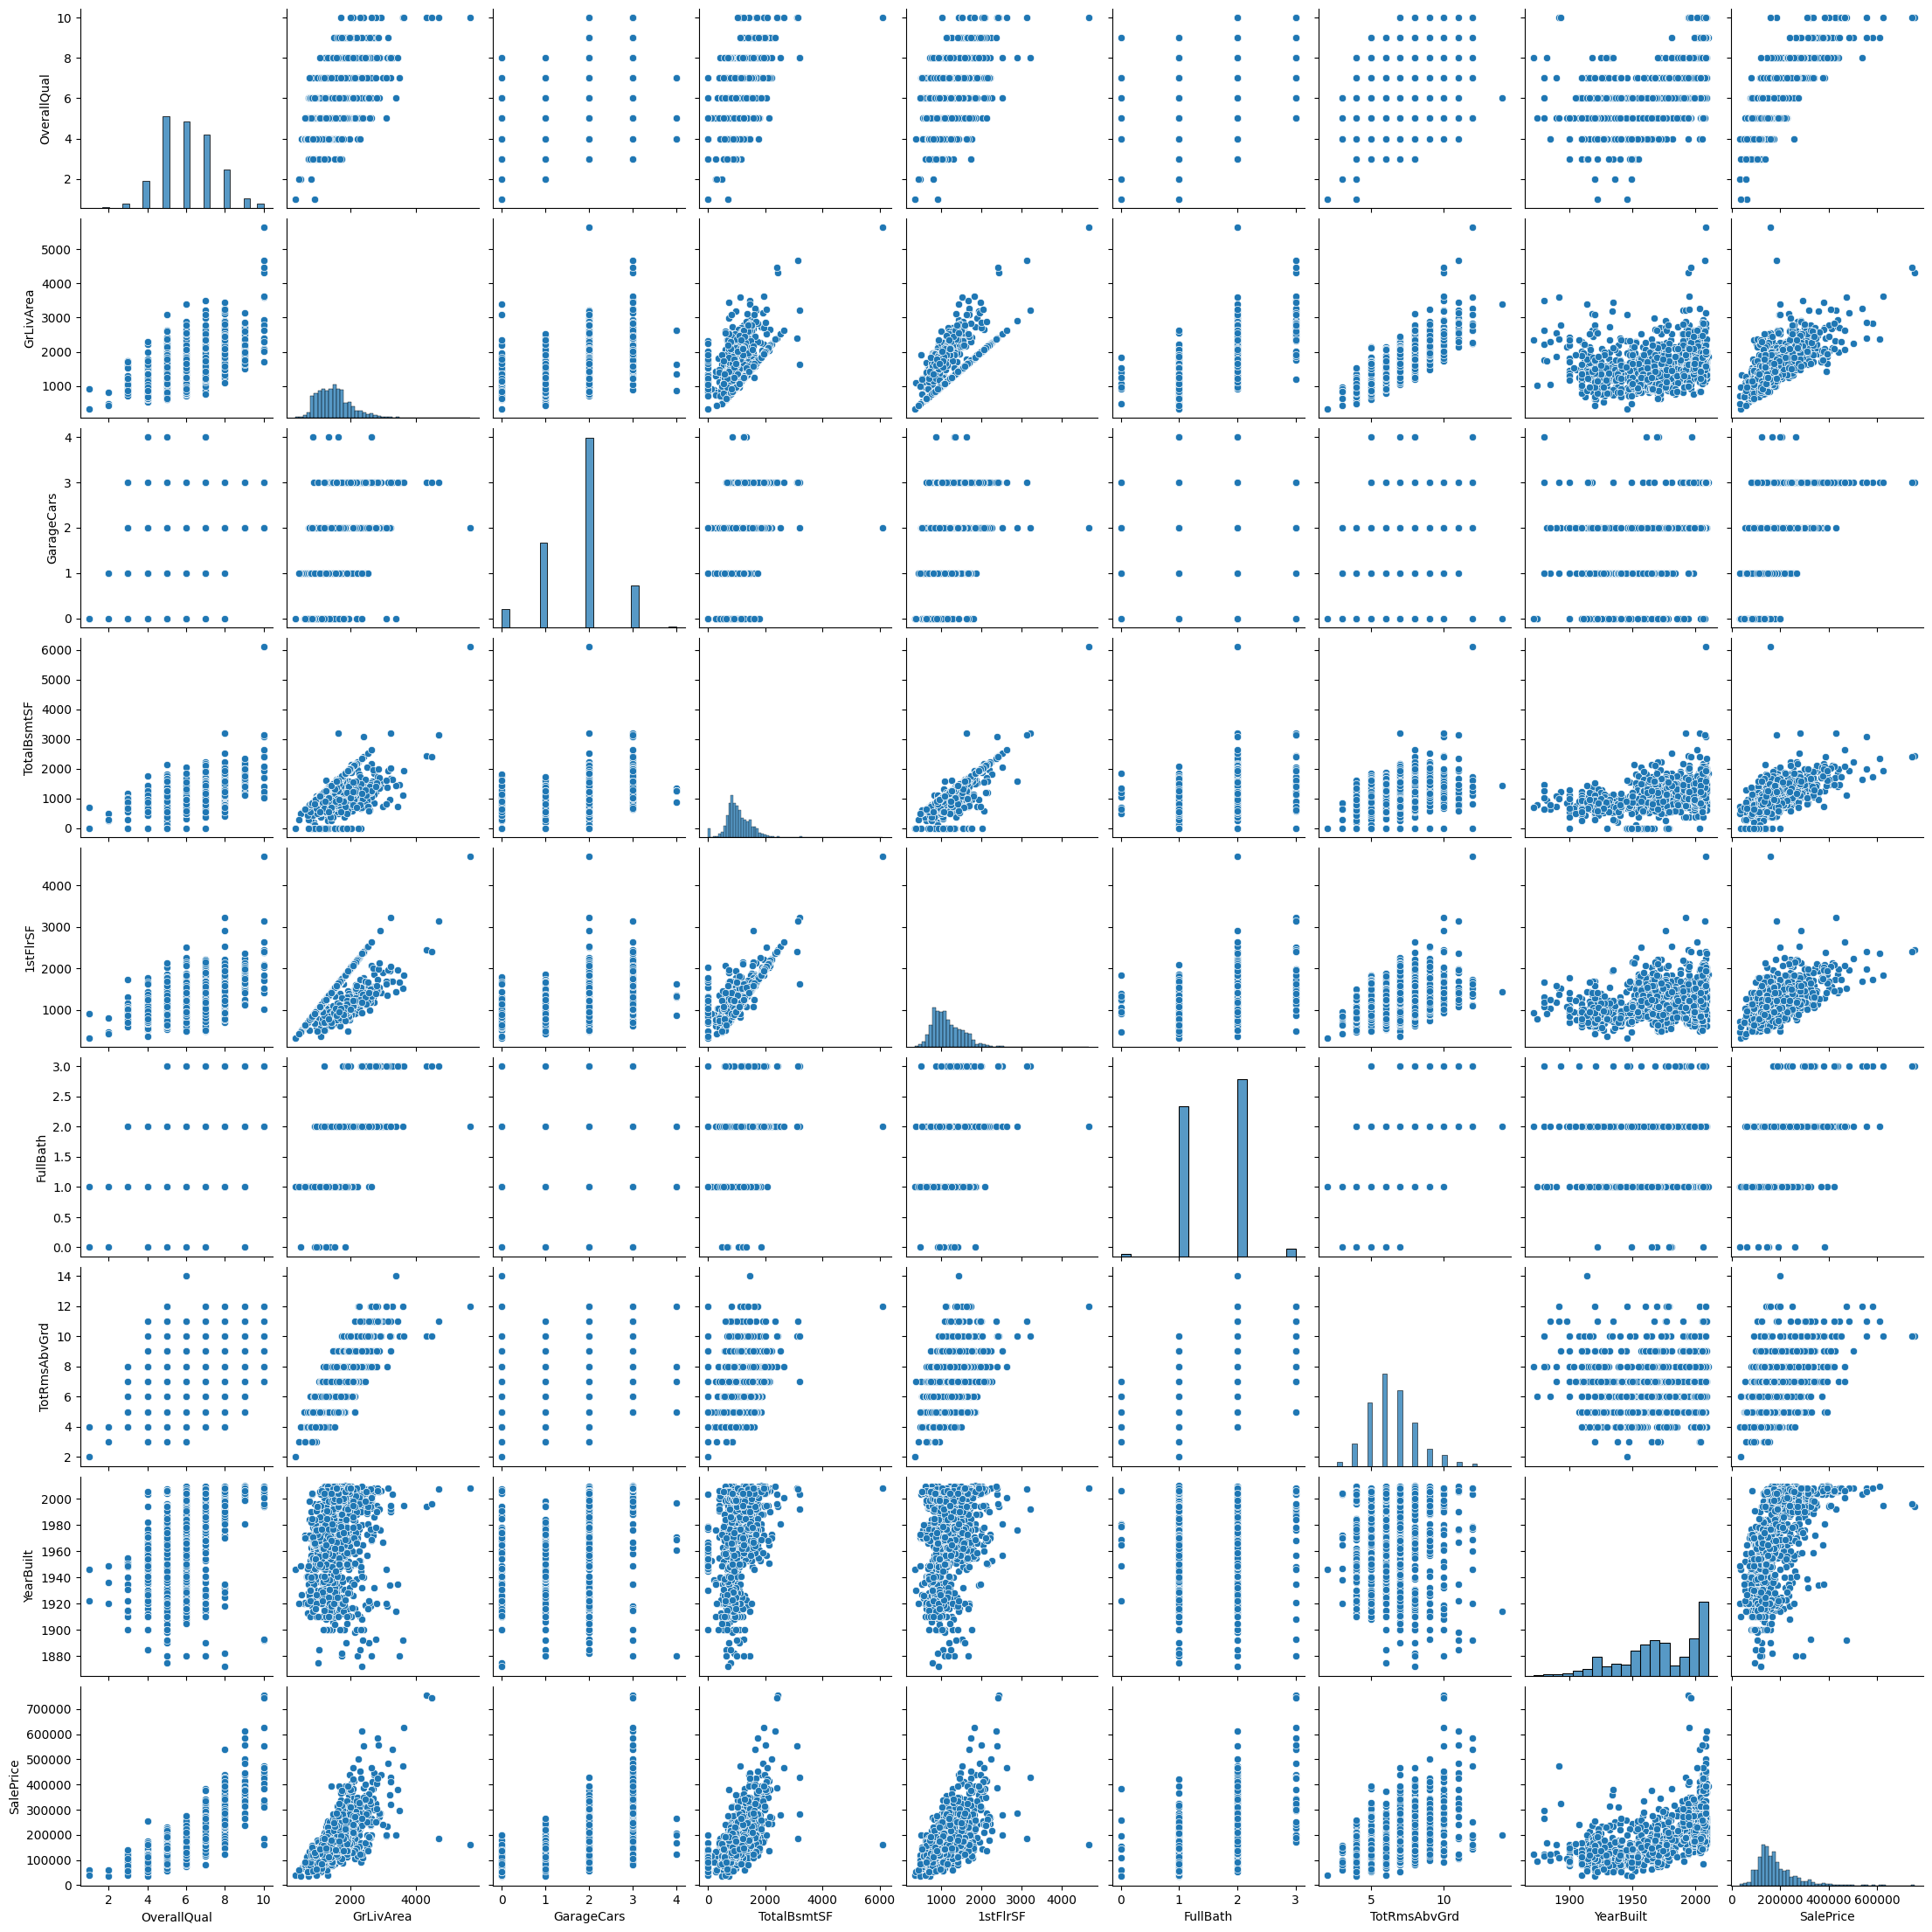

In [18]:
sns.pairplot(train_df)

# data Manipulation

In [19]:
train_df.head(5)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,SalePrice
0,7,1710,2,856,856,2,8,2003,208500
1,6,1262,2,1262,1262,2,6,1976,181500
2,7,1786,2,920,920,2,6,2001,223500
3,7,1717,3,756,961,1,7,1915,140000
4,8,2198,3,1145,1145,2,9,2000,250000


In [20]:
train_df.dtypes

OverallQual     int64
GrLivArea       int64
GarageCars      int64
TotalBsmtSF     int64
1stFlrSF        int64
FullBath        int64
TotRmsAbvGrd    int64
YearBuilt       int64
SalePrice       int64
dtype: object

In [21]:
corr = train_df.corr()['SalePrice'].sort_values(ascending=False)
print(f'Correlation:\n{corr}')

Correlation:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


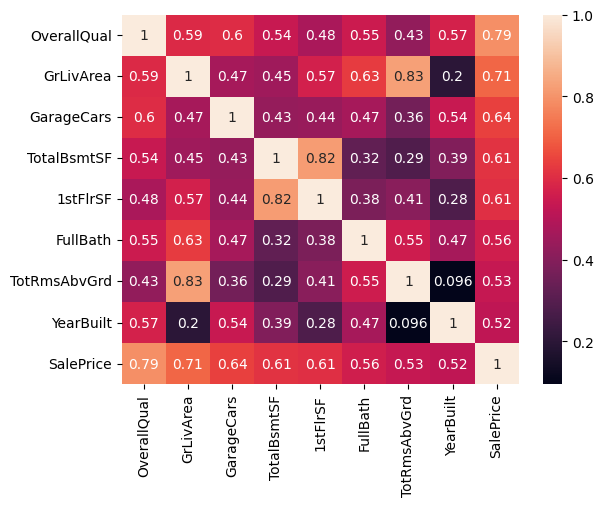

In [22]:
sns.heatmap(train_df.corr(), annot=True)
plt.show()

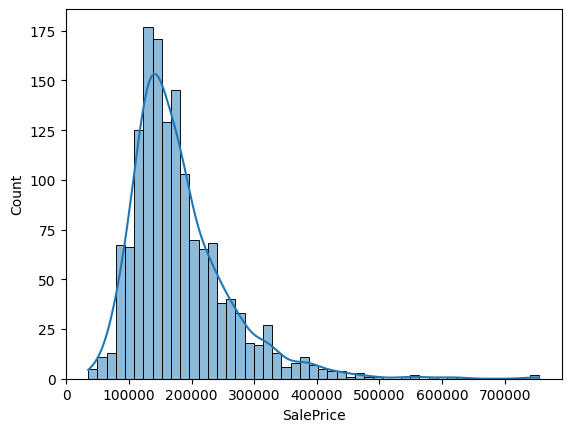

In [23]:
sns.histplot(train_df['SalePrice'], kde=True)
plt.show()

In [24]:
print(train_df['SalePrice'].skew())
print(train_df['SalePrice'].kurt())

1.8828757597682129
6.536281860064529


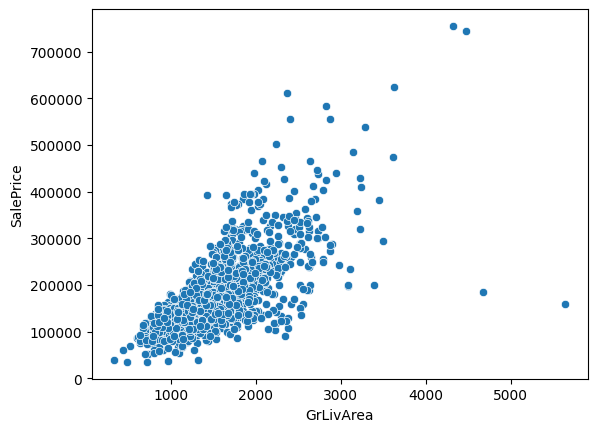

In [25]:
sns.scatterplot(train_df, x='GrLivArea', y='SalePrice')
plt.show()

In [26]:
train_df = train_df[train_df['GrLivArea'] < 4676]

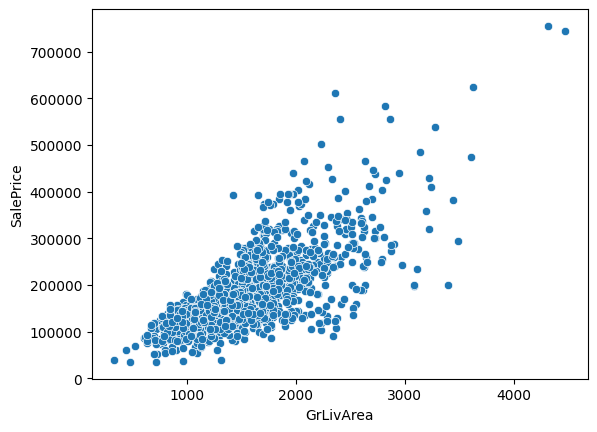

In [27]:
sns.scatterplot(train_df, x='GrLivArea', y='SalePrice')
plt.show()

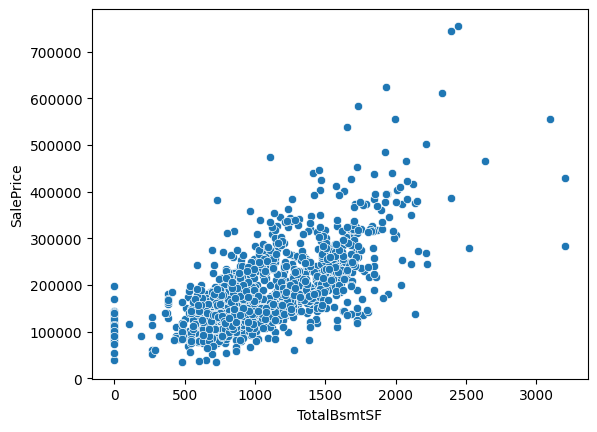

In [28]:
sns.scatterplot(train_df, x='TotalBsmtSF', y='SalePrice')
plt.show()

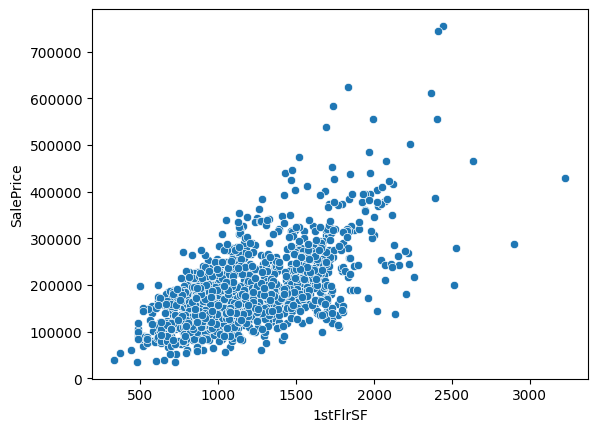

In [29]:
sns.scatterplot(train_df, x='1stFlrSF', y='SalePrice')
plt.show()

In [30]:
train_df = train_df[train_df['1stFlrSF'] < 3000]

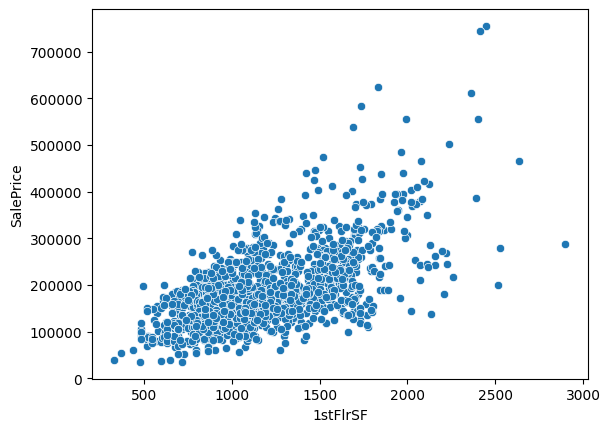

In [31]:
sns.scatterplot(train_df, x='1stFlrSF', y='SalePrice')
plt.show()

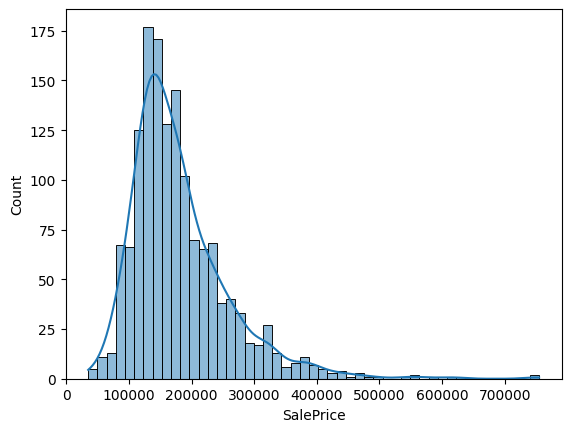

In [32]:
sns.histplot(train_df['SalePrice'], kde=True)
plt.show()

In [33]:
train_df['SalePrice'] = np.log(train_df['SalePrice'])

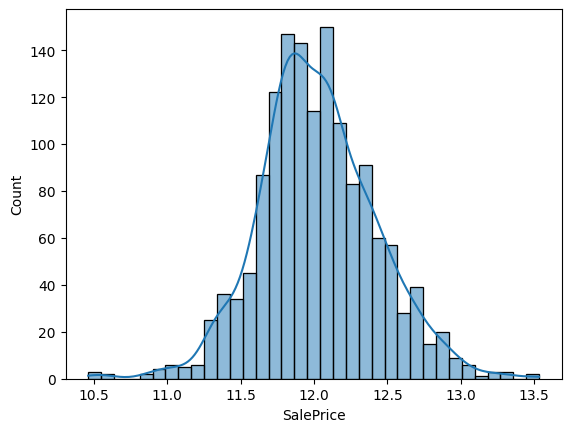

In [34]:
sns.histplot(train_df['SalePrice'], kde=True)
plt.show()

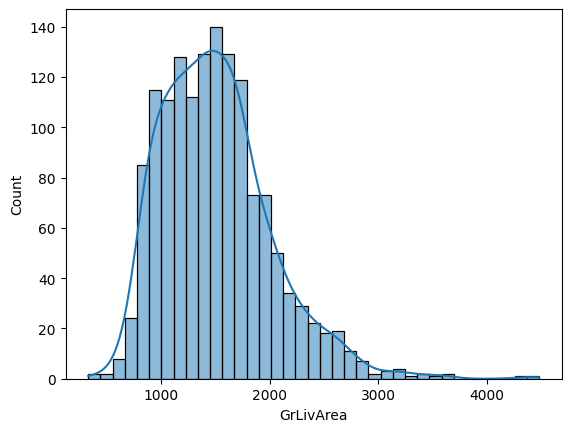

In [35]:
sns.histplot(train_df['GrLivArea'], kde=True)
plt.show()

In [36]:
train_df['GrLivArea'] = np.log(train_df['GrLivArea'])

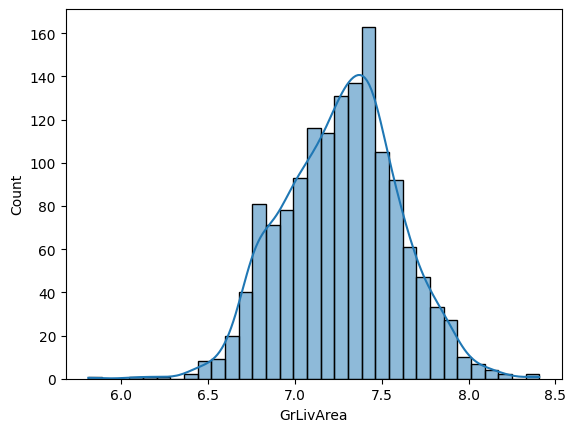

In [37]:
sns.histplot(train_df['GrLivArea'], kde=True)
plt.show()

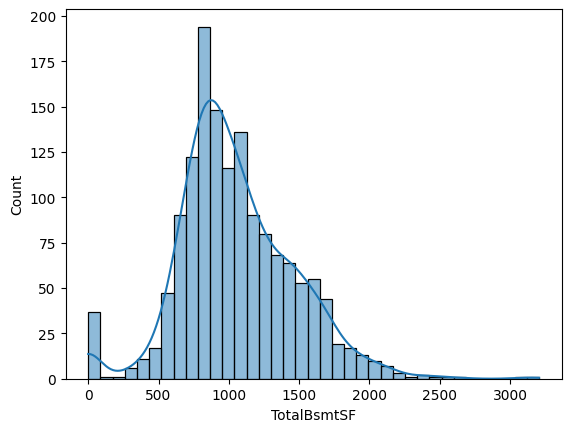

In [38]:
sns.histplot(train_df['TotalBsmtSF'], kde=True)
plt.show()

In [39]:
train_df['TotalBsmtSF'] = np.log(train_df['TotalBsmtSF'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


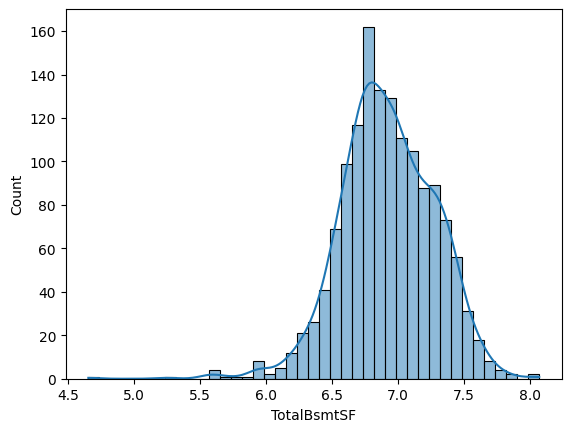

In [40]:
sns.histplot(train_df['TotalBsmtSF'], kde=True)
plt.show()

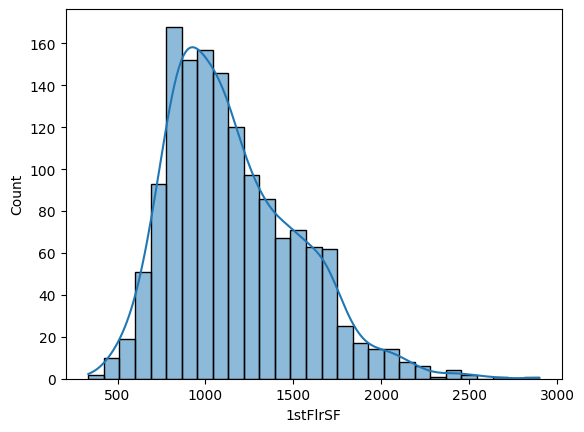

In [41]:
sns.histplot(train_df['1stFlrSF'], kde=True)
plt.show()

In [42]:
train_df['1stFlrSF'] = np.log(train_df['1stFlrSF'])

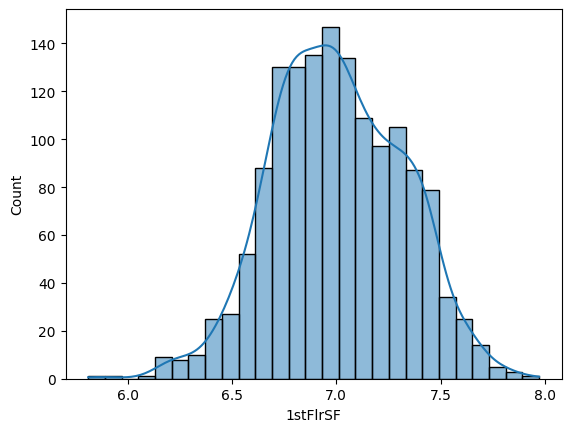

In [43]:
sns.histplot(train_df['1stFlrSF'], kde=True)
plt.show()

# Test_df

In [44]:
test_df = pd.read_csv('../input/competitions/house-prices-advanced-regression-techniques/test.csv')
test_df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [45]:
test_df.shape

(1459, 80)

In [46]:
test_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [47]:
test_df = test_df[['OverallQual', 'GrLivArea', 'GarageCars',
                   'TotalBsmtSF', '1stFlrSF', 'FullBath',
                   'TotRmsAbvGrd', 'YearBuilt']]

In [48]:
test_df.describe()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt
count,1459.000000,1459.000000,1458.000000,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,6.078821,1486.045922,1.766118,1046.117970,1156.534613,1.570939,6.385195,1971.357779
std,1.436812,485.566099,0.775945,442.898624,398.165820,0.555190,1.508895,30.390071
min,1.000000,407.000000,0.000000,0.000000,407.000000,0.000000,3.000000,1879.000000
25%,5.000000,1117.500000,1.000000,784.000000,873.500000,1.000000,5.000000,1953.000000
50%,6.000000,1432.000000,2.000000,988.000000,1079.000000,2.000000,6.000000,1973.000000
75%,7.000000,1721.000000,2.000000,1305.000000,1382.500000,2.000000,7.000000,2001.000000
max,10.000000,5095.000000,5.000000,5095.000000,5095.000000,4.000000,15.000000,2010.000000


In [49]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   1459 non-null   int64  
 1   GrLivArea     1459 non-null   int64  
 2   GarageCars    1458 non-null   float64
 3   TotalBsmtSF   1458 non-null   float64
 4   1stFlrSF      1459 non-null   int64  
 5   FullBath      1459 non-null   int64  
 6   TotRmsAbvGrd  1459 non-null   int64  
 7   YearBuilt     1459 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 91.3 KB


In [50]:
test_df.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      1
TotalBsmtSF     1
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
dtype: int64

In [51]:
test_df['GarageCars'] = test_df['GarageCars'].fillna(0)
test_df['TotalBsmtSF'] = test_df['TotalBsmtSF'].fillna(0)

In [52]:
test_df.isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
dtype: int64

In [53]:
test_df = test_df.astype(np.int64)

In [54]:
test_df.dtypes

OverallQual     int64
GrLivArea       int64
GarageCars      int64
TotalBsmtSF     int64
1stFlrSF        int64
FullBath        int64
TotRmsAbvGrd    int64
YearBuilt       int64
dtype: object

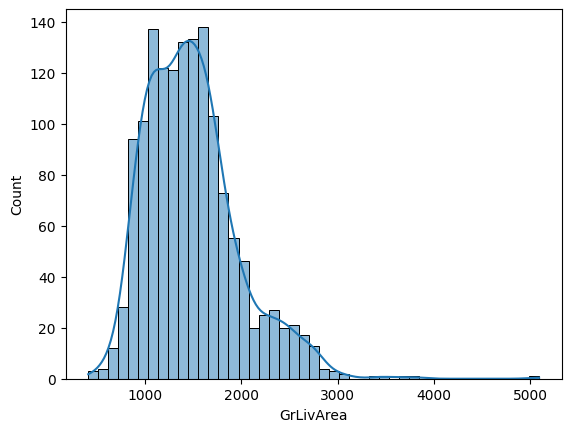

In [55]:
sns.histplot(test_df['GrLivArea'], kde=True)
plt.show()

In [56]:
test_df['GrLivArea'] = np.log(test_df['GrLivArea'])

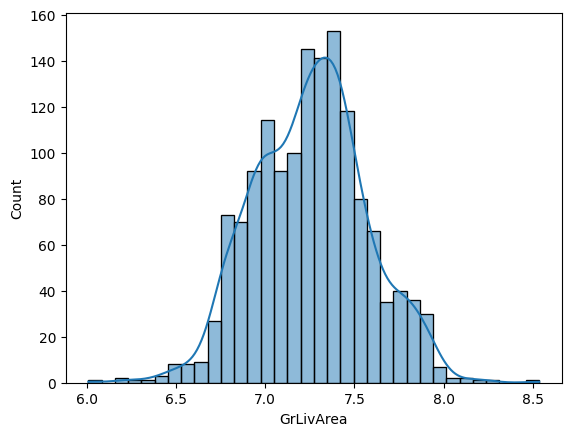

In [57]:
sns.histplot(test_df['GrLivArea'], kde=True)
plt.show()

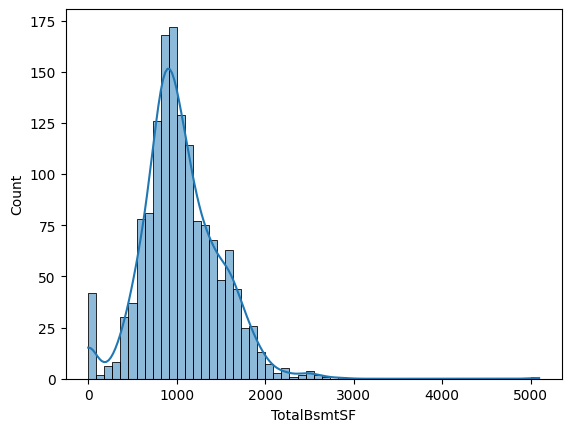

In [58]:
sns.histplot(test_df['TotalBsmtSF'], kde=True)
plt.show()

In [59]:
test_df['TotalBsmtSF'] = np.log(test_df['TotalBsmtSF'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


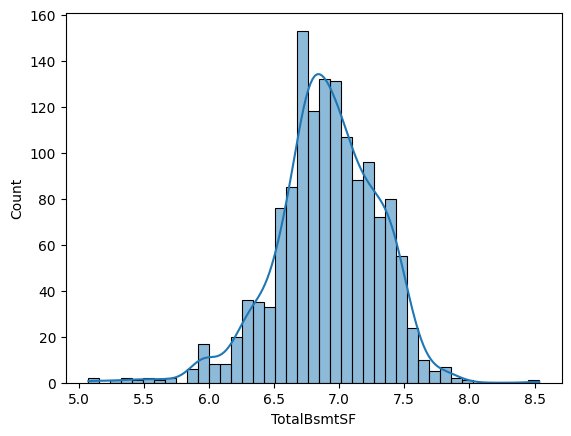

In [60]:
sns.histplot(test_df['TotalBsmtSF'], kde=True)
plt.show()

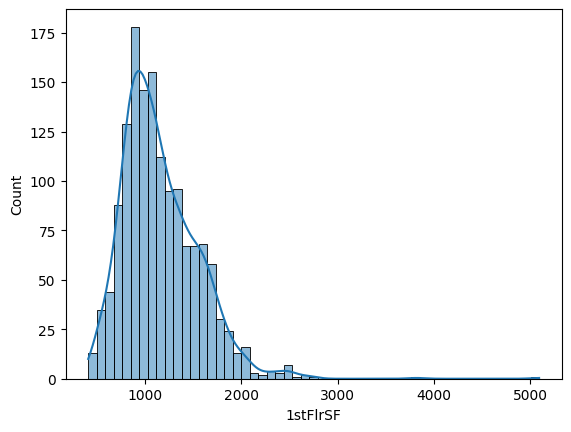

In [61]:
sns.histplot(test_df['1stFlrSF'], kde=True)
plt.show()

In [62]:
test_df['1stFlrSF'] = np.log(test_df['1stFlrSF'])

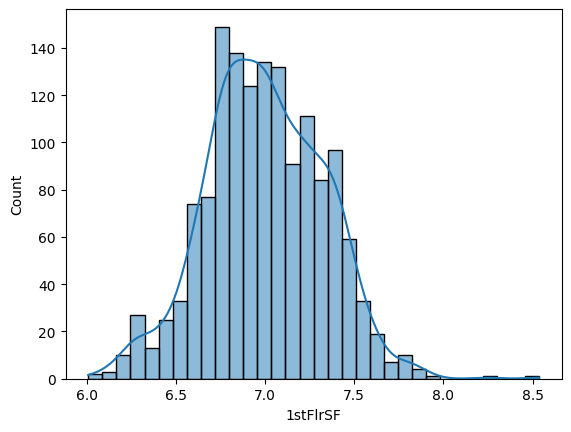

In [63]:
sns.histplot(test_df['1stFlrSF'], kde=True)
plt.show()

In [64]:
train_df.head(5)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,SalePrice
0,7,7.444249,2,6.752270,6.752270,2,8,2003,12.247694
1,6,7.140453,2,7.140453,7.140453,2,6,1976,12.109011
2,7,7.487734,2,6.824374,6.824374,2,6,2001,12.317167
3,7,7.448334,3,6.628041,6.867974,1,7,1915,11.849398
4,8,7.695303,3,7.043160,7.043160,2,9,2000,12.429216


In [65]:
test_df.head(5)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt
0,5,6.797940,1,6.782192,6.797940,1,5,1961
1,6,7.192182,1,7.192182,7.192182,1,6,1958
2,5,7.395722,2,6.833032,6.833032,2,6,1997
3,6,7.380256,2,6.830874,6.830874,2,7,1998
4,8,7.154615,2,7.154615,7.154615,2,5,1992


# Training Models

# Splitting dataset

In [66]:
X = train_df.drop('SalePrice', axis=1)
y = train_df['SalePrice']
X_test = test_df

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Data Normalization

In [68]:
print(np.isinf(X_train).sum())
print(np.isnan(X_train).sum())

OverallQual      0
GrLivArea        0
GarageCars       0
TotalBsmtSF     32
1stFlrSF         0
FullBath         0
TotRmsAbvGrd     0
YearBuilt        0
dtype: int64
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
dtype: int64


In [69]:
print(np.isinf(X_test).sum())
print(np.isnan(X_test).sum())

OverallQual      0
GrLivArea        0
GarageCars       0
TotalBsmtSF     42
1stFlrSF         0
FullBath         0
TotRmsAbvGrd     0
YearBuilt        0
dtype: int64
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
1stFlrSF        0
FullBath        0
TotRmsAbvGrd    0
YearBuilt       0
dtype: int64


In [70]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val = X_val.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [71]:
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ML Models

In [73]:
from sklearn.linear_model import LinearRegression

In [74]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

LinearRegression()

In [75]:
y_pred_lin_reg = lin_reg.predict(X_val_scaled)

In [76]:
print(f'Mean Absolute Error for linear regression = {mean_absolute_error(y_val, y_pred_lin_reg)}')
print(f'Mean Squared Error for linear regression = {mean_squared_error(y_val, y_pred_lin_reg)}')
print(f'R2 for linear regression = {r2_score(y_val, y_pred_lin_reg)}')

Mean Absolute Error for linear regression = 0.11879083264178482
Mean Squared Error for linear regression = 0.027502356043031227
R2 for linear regression = 0.8326196971147093


In [77]:
from sklearn.svm import SVR

In [78]:
svr = SVR(kernel='linear', C=0.1)
svr.fit(X_train_scaled, y_train)

SVR(C=0.1, kernel='linear')

In [79]:
y_pred_svr = svr.predict(X_val_scaled)

In [80]:
print(f'Mean Absolute Error for SVR = {mean_absolute_error(y_val, y_pred_svr)}')
print(f'Mean Squared Error for SVR = {mean_squared_error(y_val, y_pred_svr)}')
print(f'R2 for SVR = {r2_score(y_val, y_pred_svr)}')

Mean Absolute Error for SVR = 0.11845865842832462
Mean Squared Error for SVR = 0.02789119535149555
R2 for SVR = 0.8302532074538732


In [81]:
from sklearn.neighbors import KNeighborsRegressor

In [82]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor()

In [83]:
y_pred_knn = knn.predict(X_val_scaled)

In [84]:
print(f'Mean Absolute Error for KNN = {mean_absolute_error(y_val, y_pred_knn)}')
print(f'Mean Squared Error for KNN = {mean_squared_error(y_val, y_pred_knn)}')
print(f'R2 for KNN = {r2_score(y_val, y_pred_knn)}')

Mean Absolute Error for KNN = 0.11873777970653401
Mean Squared Error for KNN = 0.030904594438252497
R2 for KNN = 0.8119135549867733


In [85]:
from sklearn.tree import DecisionTreeRegressor

In [86]:
dt = DecisionTreeRegressor(max_depth=5)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5)

In [87]:
y_pred_dt = dt.predict(X_val)

In [88]:
print(f'Mean Absolute Error for decision tree = {mean_absolute_error(y_val, y_pred_dt)}')
print(f'Mean Squared Error for decision tree = {mean_squared_error(y_val, y_pred_dt)}')
print(f'R2 for decision tree = {r2_score(y_val, y_pred_dt)}')

Mean Absolute Error for decision tree = 0.13696946354473033
Mean Squared Error for decision tree = 0.03698417835677497
R2 for decision tree = 0.7749129941582154


In [89]:
from sklearn.ensemble import RandomForestRegressor

In [90]:
rf = RandomForestRegressor(n_estimators=100, max_depth=7)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=7)

In [91]:
y_pred_rf = rf.predict(X_val)

In [92]:
print(f'Mean Absolute Error for random forest = {mean_absolute_error(y_val, y_pred_rf)}')
print(f'Mean Squared Error for random forest = {mean_squared_error(y_val, y_pred_rf)}')
print(f'R2 for random forest = {r2_score(y_val, y_pred_rf)}')

Mean Absolute Error for random forest = 0.11015108623297007
Mean Squared Error for random forest = 0.026242529626994034
R2 for random forest = 0.8402870448419097


In [93]:
from sklearn.ensemble import GradientBoostingRegressor

In [94]:
gb = GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(n_estimators=50, random_state=42)

In [95]:
y_pred_gb = gb.predict(X_val)

In [96]:
print(f'Mean Absolute Error for gradientBoosting = {mean_absolute_error(y_val, y_pred_gb)}')
print(f'Mean Squared Error for gradientBoosting = {mean_squared_error(y_val, y_pred_gb)}')
print(f'R2 for gradientBoosting = {r2_score(y_val, y_pred_gb)}')

Mean Absolute Error for gradientBoosting = 0.10722726461834782
Mean Squared Error for gradientBoosting = 0.024826623633431667
R2 for gradientBoosting = 0.8489042983488004


In [97]:
from xgboost import XGBRegressor

In [98]:
xgb = XGBRegressor(n_estimators=50, max_depth=3)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [99]:
y_pred_xgb = xgb.predict(X_val)

In [100]:
print(f'Mean Absolute Error for xgboost = {mean_absolute_error(y_val, y_pred_xgb)}')
print(f'Mean Squared Error for xgboost = {mean_squared_error(y_val, y_pred_xgb)}')
print(f'R2 for xgboost = {r2_score(y_val, y_pred_xgb)}')

Mean Absolute Error for xgboost = 0.10983195528119141
Mean Squared Error for xgboost = 0.02544281890907396
R2 for xgboost = 0.8451541123024808


In [101]:
data_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'KNN',
        'SVM',
        'Random Forest',
        'Decision Tree',
        'Gradient Boosting',
        'XGBoost'
    ],
    'R2_Score': [
        r2_score(y_val, y_pred_lin_reg),
        r2_score(y_val, y_pred_knn),
        r2_score(y_val, y_pred_svr),
        r2_score(y_val, y_pred_rf),
        r2_score(y_val, y_pred_dt),
        r2_score(y_val, y_pred_gb),
        r2_score(y_val, y_pred_xgb)
    ]
}).sort_values(by='R2_Score', ascending=False)

data_df

,Model,R2_Score
5,Gradient Boosting,0.848904
6,XGBoost,0.845154
3,Random Forest,0.840287
0,Linear Regression,0.832620
2,SVM,0.830253
1,KNN,0.811914
4,Decision Tree,0.774913


# The best model is Gradient Boosting

In [102]:
y_pred = gb.predict(X_test)

In [103]:
y_pred[:5]

array([11.74973701, 11.9061163 , 12.02413701, 12.09892045, 12.23339353])

In [104]:
y_pred = np.expm1(y_pred)

In [105]:
y_pred[:5]

array([126719.22797431, 148169.11157598, 166729.99957968, 179676.78555694,
       205538.50381317])

In [106]:
data = pd.read_csv('../input/competitions/house-prices-advanced-regression-techniques/test.csv')
data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [107]:
submission = pd.DataFrame({
    'Id':data['Id'],
    'SalePrice':y_pred
})

In [108]:
submission.head(5)

,Id,SalePrice
0,1461,126719.227974
1,1462,148169.111576
2,1463,166729.999580
3,1464,179676.785557
4,1465,205538.503813


In [109]:
submission.to_csv('submission.csv', index=False)